<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [9]:
# Carrega o dataset Iris
iris = load_iris()
X, y = iris.data, iris.target

# Divisão estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Total de amostras  : {len(X)}")
print(f"Treino             : {len(X_train)} amostras")
print(f"Teste              : {len(X_test)} amostras")
print()
print("Distribuição de classes no treino:", np.bincount(y_train))
print("Distribuição de classes no teste :", np.bincount(y_test))

Total de amostras  : 150
Treino             : 120 amostras
Teste              : 30 amostras

Distribuição de classes no treino: [40 40 40]
Distribuição de classes no teste : [10 10 10]


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [10]:
# Treina a árvore de decisão
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Acurácia em treino e teste
acc_train = accuracy_score(y_train, tree.predict(X_train))
acc_test  = accuracy_score(y_test,  tree.predict(X_test))

print(f"Acurácia no treino : {acc_train:.4f} ({acc_train*100:.1f}%)")
print(f"Acurácia no teste  : {acc_test:.4f} ({acc_test*100:.1f}%)")

Acurácia no treino : 1.0000 (100.0%)
Acurácia no teste  : 0.9333 (93.3%)


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

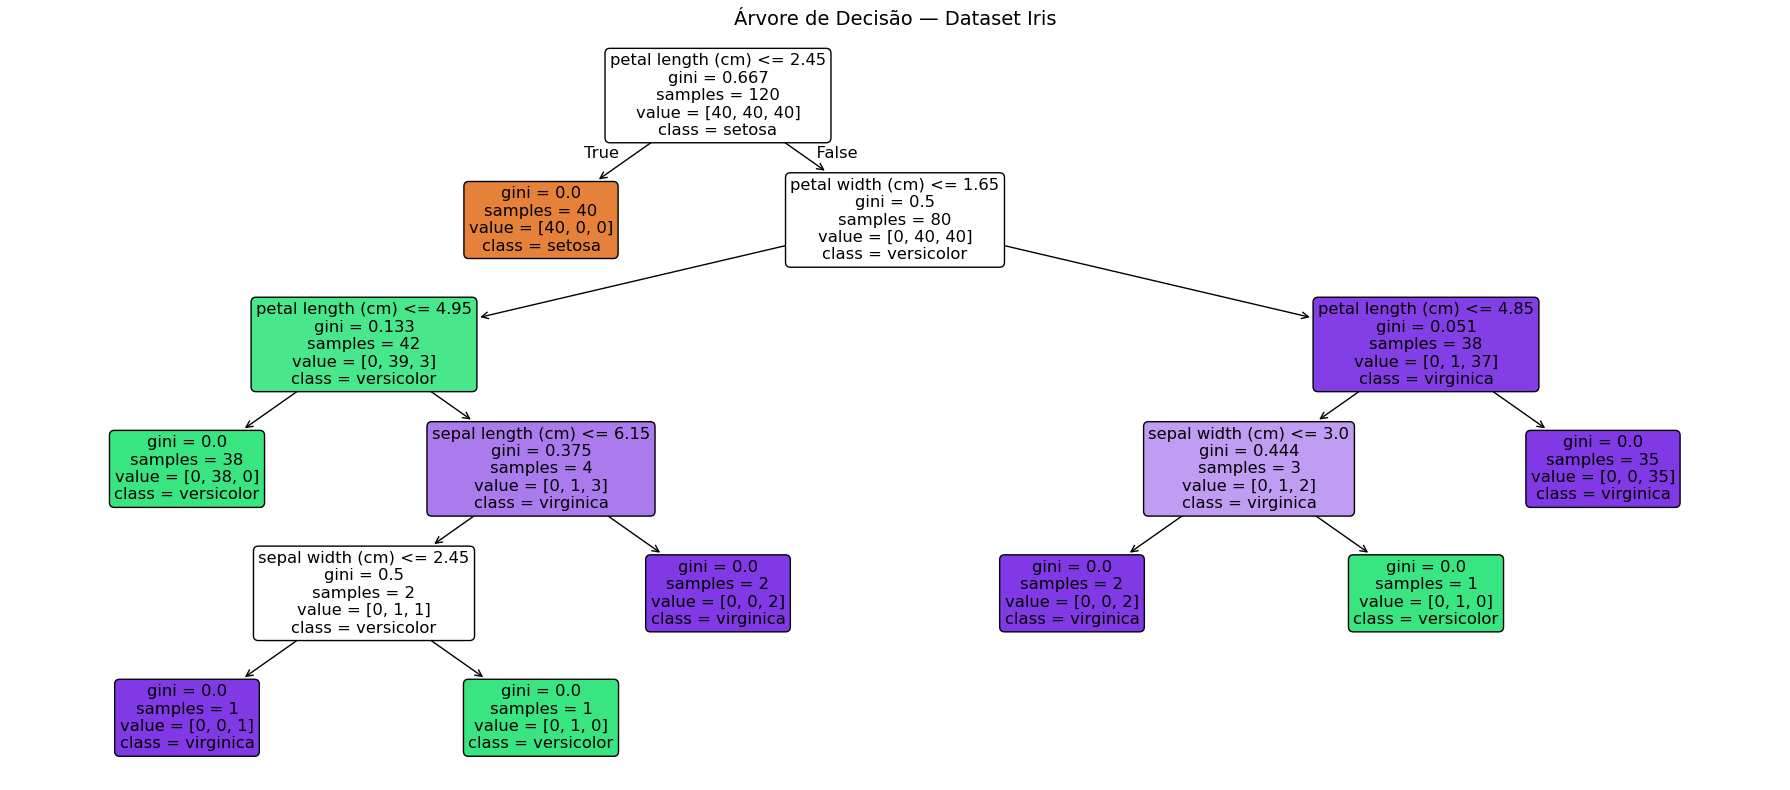

Atributo na raiz   : petal length (cm)
Profundidade       : 5
Número de folhas   : 8


In [11]:
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    ax=ax
)
plt.title("Árvore de Decisão — Dataset Iris", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Atributo na raiz   : {iris.feature_names[tree.tree_.feature[0]]}")
print(f"Profundidade       : {tree.get_depth()}")
print(f"Número de folhas   : {tree.get_n_leaves()}")

Respostas:

1. Qual atributo aparece na raiz?
O atributo na raiz é petal length (cm). Isso significa que ele é o mais discriminativo do dataset, ou seja, é o que melhor separa as classes logo no primeiro corte. O sklearn escolhe o atributo que maximiza a redução de impureza Gini, e o comprimento da pétala consegue separar a classe setosa das demais de forma quase perfeita já na raiz.

2. Qual é a profundidade da árvore?
A árvore tem profundidade 5 e 8 folhas. Com profundidade irrestrita (max_depth=None), o modelo cresce até que cada folha contenha amostras de uma única classe, atingindo 100% de acurácia no treino. Isso indica que a árvore memorizou os dados de treino, o que pode prejudicar a generalização para novos exemplos — característica clássica de overfitting em árvores sem regularização.

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

max_depth  profundidade  folhas  acc_treino  acc_teste    gap
        1             1       2      0.6667     0.6667 0.0000
        2             2       3      0.9667     0.9333 0.0333
        3             3       5      0.9833     0.9667 0.0167
        4             4       7      0.9917     0.9333 0.0583
        5             5       8      1.0000     0.9333 0.0667
        6             5       8      1.0000     0.9333 0.0667
        7             5       8      1.0000     0.9333 0.0667
        8             5       8      1.0000     0.9333 0.0667
        9             5       8      1.0000     0.9333 0.0667
     None             5       8      1.0000     0.9333 0.0667


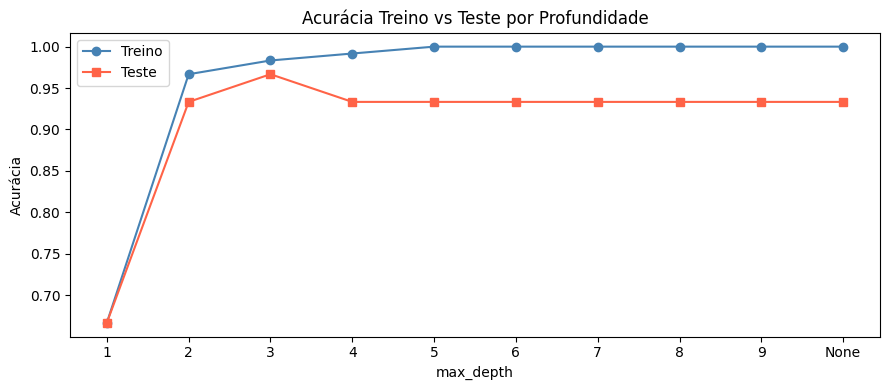

In [12]:
max_depths = list(range(1, 10)) + [None]
results = []

for md in max_depths:
    clf = DecisionTreeClassifier(max_depth=md, random_state=42)
    clf.fit(X_train, y_train)

    acc_tr = accuracy_score(y_train, clf.predict(X_train))
    acc_te = accuracy_score(y_test,  clf.predict(X_test))

    results.append({
        'max_depth'   : str(md) if md is not None else 'None',
        'profundidade': clf.get_depth(),
        'folhas'      : clf.get_n_leaves(),
        'acc_treino'  : round(acc_tr, 4),
        'acc_teste'   : round(acc_te, 4),
        'gap'         : round(acc_tr - acc_te, 4)
    })

df = pd.DataFrame(results)
print(df.to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(results))
ax.plot(x, df['acc_treino'], 'o-', label='Treino', color='steelblue')
ax.plot(x, df['acc_teste'],  's-', label='Teste',  color='tomato')
ax.set_xticks(list(x))
ax.set_xticklabels(df['max_depth'])
ax.set_xlabel('max_depth')
ax.set_ylabel('Acurácia')
ax.set_title('Acurácia Treino vs Teste por Profundidade')
ax.legend()
plt.tight_layout()
plt.show()

**Em qual profundidade começa o overfitting?**

O overfitting começa em max_depth=4. A partir dessa profundidade, a acurácia de treino atinge 100% enquanto a acurácia de teste cai de 96,67% (que foi o pico em max_depth=3) para 93,33% e permanece estagnada. O gap treino-teste salta de 0,0167 para 0,0583 em max_depth=4 e se estabiliza em 0,0667 a partir de max_depth=5. Isso indica que o modelo passou a memorizar os dados de treino em vez de aprender padrões generalizáveis.

**Por que a árvore consegue 100% no treino quando max_depth=None?**

Com profundidade irrestrita, a árvore cresce até esgotar completamente os dados de treino — neste caso, atingindo profundidade 5 e 8 folhas. Cada folha termina contendo apenas amostras de uma única classe, o que significa que o modelo criou uma regra específica para cada grupo de exemplos do treino. O resultado é acurácia perfeita no treino (100%), mas sem ganho no teste, que permanece em 93,33% — o mesmo de max_depth=5. Isso confirma que profundidades maiores que 3 não agregam capacidade de generalização neste dataset.

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

  Critério | Profundidade | Folhas |   Treino |    Teste
-------------------------------------------------------
      gini |            5 |      8 |   1.0000 |   0.9333
   entropy |            5 |      8 |   1.0000 |   0.9333


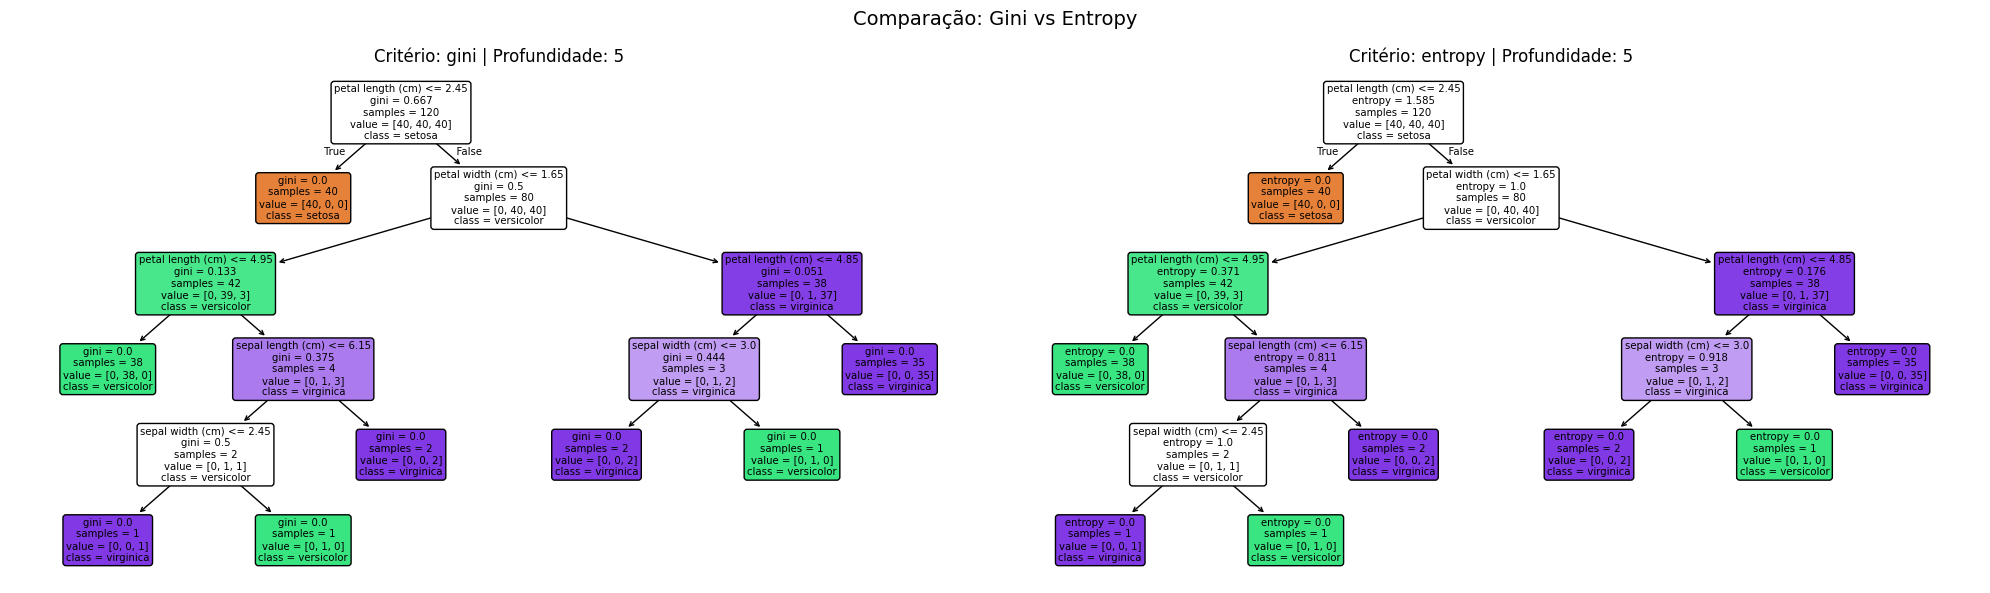

In [13]:
criteria = ['gini', 'entropy']

print(f"{'Critério':>10} | {'Profundidade':>12} | {'Folhas':>6} | {'Treino':>8} | {'Teste':>8}")
print("-" * 55)

for crit in criteria:
    clf = DecisionTreeClassifier(criterion=crit, random_state=42)
    clf.fit(X_train, y_train)

    acc_tr = accuracy_score(y_train, clf.predict(X_train))
    acc_te = accuracy_score(y_test,  clf.predict(X_test))

    print(f"{crit:>10} | {clf.get_depth():>12} | {clf.get_n_leaves():>6} | {acc_tr:>8.4f} | {acc_te:>8.4f}")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, crit in zip(axes, criteria):
    clf = DecisionTreeClassifier(criterion=crit, random_state=42)
    clf.fit(X_train, y_train)
    plot_tree(
        clf,
        feature_names=iris.feature_names,
        class_names=iris.target_names,
        filled=True,
        rounded=True,
        ax=ax
    )
    ax.set_title(f"Critério: {crit} | Profundidade: {clf.get_depth()}", fontsize=12)

plt.suptitle("Comparação: Gini vs Entropy", fontsize=14)
plt.tight_layout()
plt.show()

Os dois critérios produziram resultados idênticos neste dataset: mesma profundidade (5), mesmo número de folhas (8), mesma acurácia no treino (100%) e no teste (93,33%). Visualmente, as árvores também têm estrutura muito similar, diferindo apenas nos valores internos de impureza exibidos em cada nó (gini vs entropy).
Isso acontece porque Gini e Entropy são medidas matematicamente próximas — ambas medem impureza de uma partição e tendem a escolher os mesmos atributos para dividir os dados. Em datasets pequenos e bem separados como o Iris, essa diferença praticamente desaparece. Em datasets maiores e mais complexos, o Entropy pode gerar árvores ligeiramente diferentes por ser mais sensível a divisões com baixa pureza, já que usa logaritmo no cálculo, penalizando mais as impurezas intermediárias.

# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

 min_samples_leaf  profundidade  folhas  acc_treino  acc_teste
                1             5       8      1.0000     0.9333
                2             4       6      0.9833     0.9333
                3             3       5      0.9833     0.9667
                5             3       5      0.9667     0.9333
                7             3       5      0.9667     0.9333
               10             3       5      0.9667     0.9333
               15             3       5      0.9667     0.9333
               20             3       4      0.9667     0.9333

Melhor modelo:
  min_samples_leaf : 3
  Profundidade     : 3
  Acurácia treino  : 0.9833
  Acurácia teste   : 0.9667


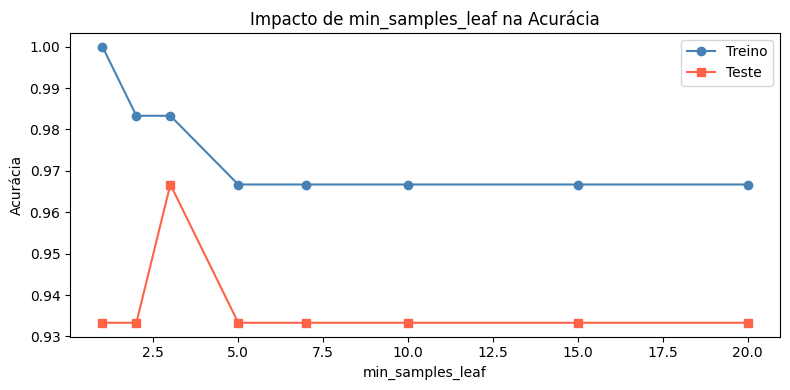

In [14]:
min_leaf_values = [1, 2, 3, 5, 7, 10, 15, 20]
results_q6 = []

for msl in min_leaf_values:
    clf = DecisionTreeClassifier(min_samples_leaf=msl, random_state=42)
    clf.fit(X_train, y_train)

    acc_tr = accuracy_score(y_train, clf.predict(X_train))
    acc_te = accuracy_score(y_test,  clf.predict(X_test))

    results_q6.append({
        'min_samples_leaf': msl,
        'profundidade'    : clf.get_depth(),
        'folhas'          : clf.get_n_leaves(),
        'acc_treino'      : round(acc_tr, 4),
        'acc_teste'       : round(acc_te, 4)
    })

df_q6 = pd.DataFrame(results_q6)
print(df_q6.to_string(index=False))

# Melhor modelo
best = df_q6.loc[df_q6['acc_teste'].idxmax()]
print(f"\nMelhor modelo:")
print(f"  min_samples_leaf : {int(best['min_samples_leaf'])}")
print(f"  Profundidade     : {int(best['profundidade'])}")
print(f"  Acurácia treino  : {best['acc_treino']:.4f}")
print(f"  Acurácia teste   : {best['acc_teste']:.4f}")

# Gráfico
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_q6['min_samples_leaf'], df_q6['acc_treino'], 'o-', label='Treino', color='steelblue')
ax.plot(df_q6['min_samples_leaf'], df_q6['acc_teste'],  's-', label='Teste',  color='tomato')
ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('Acurácia')
ax.set_title('Impacto de min_samples_leaf na Acurácia')
ax.legend()
plt.tight_layout()
plt.show()

O melhor modelo foi com min_samples_leaf=3, atingindo 96,67% no teste com profundidade 3 e 5 folhas — e ainda com menor gap treino-teste (0,0167) em comparação ao valor padrão de 1. Com min_samples_leaf=1 (padrão), o modelo sofre overfitting: treino 100% mas teste 93,33%. Ao exigir no mínimo 3 amostras por folha, o modelo ficou menos específico e generalizou melhor.
A partir de min_samples_leaf=5, a acurácia de teste cai de volta para 93,33% e permanece estagnada até o valor 20, indicando underfitting: o modelo ficou restrito demais, com apenas 3 de profundidade e 4–5 folhas, incapaz de capturar algumas distinções importantes entre as classes. O gráfico deixa isso claro — há um pico isolado em min_samples_leaf=3, com queda abrupta para os dois lados, mostrando que esse é o ponto ideal de equilíbrio entre bias e variância para este dataset.